## 📦 Setup & Installation

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Navigate to project
import os
%cd /content/drive/MyDrive/maml-dynamic-portfolio-allocation
!pwd

/content/drive/MyDrive/maml-dynamic-portfolio-allocation
/content/drive/MyDrive/maml-dynamic-portfolio-allocation


In [3]:
# Install dependencies
!pip install -q torch pandas matplotlib tqdm scikit-learn numpy

In [4]:
!apt-get install -y build-essential
!pip install setuptools wheel Cython
!pip install learn2learn==0.1.0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for learn2learn: filename=learn2learn-0.1.0-cp312-cp312-linux_x86_64.whl size=1363242 sha256=5585511d6bdebbcc00a9d2a3d301541c0600bc6af212648444239adf110728c2
  Stored in directory: /root/.cache/pip/wheels/f0/36/6f/6d5f43138970981f701f9b928032b5ff29aa606ae3e49fafcf
Successfully built learn2learn


## 🔍 Load 20d Threshold Data

In [8]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Load NEW task metadata (20d threshold)
with open('data/jm/20d_threshold/tasks_metadata_20d.json', 'r') as f:
    tasks_metadata = json.load(f)

# Load NEW splits
with open('data/jm/20d_threshold/task_split_indices_20d.json', 'r') as f:
    splits = json.load(f)

train_ids = splits['train']
val_ids = splits['val']
test_ids = splits['test']

print("📊 Dataset Statistics (20d threshold)")
print("=" * 60)
print(f"Total tasks: {len(tasks_metadata)}")
print(f"Train tasks: {len(train_ids)}")
print(f"Val tasks: {len(val_ids)}")
print(f"Test tasks: {len(test_ids)}")

# Count regime distribution
regime_counts = {0: 0, 1: 0, 2: 0}
for task in tasks_metadata:
    regime_counts[task['regime']] += 1

print(f"\nRegime Distribution:")
print(f"  JR0 (Calm):     {regime_counts[0]} tasks")
print(f"  JR1 (Moderate): {regime_counts[1]} tasks")
print(f"  JR2 (Crisis):   {regime_counts[2]} tasks ⭐ (+2 from 30d!)")

# Show all JR2 crisis tasks
jr2_tasks = [t for t in tasks_metadata if t['regime'] == 2]
print(f"\n🚨 All {len(jr2_tasks)} Crisis Tasks (JR2):")
for task in sorted(jr2_tasks, key=lambda x: x['start_date']):
    year = task['start_date'][:4]
    new_marker = "⭐ NEW!" if task['task_id'] in [63, 68] else ""
    print(f"  Task {task['task_id']}: {task['start_date']} to {task['end_date']} "
          f"({task['length']}d, jump_freq={task['jump_frequency']*100:.1f}%) {new_marker}")

📊 Dataset Statistics (20d threshold)
Total tasks: 69
Train tasks: 35
Val tasks: 8
Test tasks: 26

Regime Distribution:
  JR0 (Calm):     31 tasks
  JR1 (Moderate): 31 tasks
  JR2 (Crisis):   7 tasks ⭐ (+2 from 30d!)

🚨 All 7 Crisis Tasks (JR2):
  Task 62: 1998-08-31 to 1998-09-30 (21d, jump_freq=18.2%) 
  Task 63: 2002-07-23 to 2002-08-22 (22d, jump_freq=13.0%) ⭐ NEW!
  Task 64: 2008-09-18 to 2009-01-06 (75d, jump_freq=40.8%) 
  Task 65: 2009-02-24 to 2009-04-07 (30d, jump_freq=19.4%) 
  Task 66: 2011-08-09 to 2011-09-08 (21d, jump_freq=18.2%) 
  Task 67: 2020-03-04 to 2020-04-24 (36d, jump_freq=37.8%) 
  Task 68: 2025-04-07 to 2025-05-06 (20d, jump_freq=4.8%) ⭐ NEW!


## 📈 Load Features

In [9]:
# Load features
try:
    features_df = pd.read_csv('data/processed/features_imputed_with_targets.csv', parse_dates=['Date'])
    print(f"✅ Loaded features: {features_df.shape}")
except FileNotFoundError:
    # Fallback: create from jump data
    regime_labels = pd.read_csv('data/jm/jump_regime_labels.csv', parse_dates=['Date'])
    jump_indicators = pd.read_csv('data/jm/jump_indicators_simple.csv', parse_dates=['Date'])
    sp500_data = pd.read_csv('data/processed/sp500_vix_merged_clean.csv', parse_dates=['Date'])

    features_df = regime_labels.merge(jump_indicators, on='Date', how='inner')
    features_df = features_df.merge(sp500_data[['Date', 'Close', 'Volume', 'VIX']], on='Date', how='inner')

    features_df['return_1d'] = features_df['Close'].pct_change()
    features_df['volatility_20d'] = features_df['return_1d'].rolling(20).std()
    features_df['target_return_1d'] = features_df['return_1d'].shift(-1)

    print(f"✅ Created features: {features_df.shape}")

print(f"Date range: {features_df['Date'].min()} to {features_df['Date'].max()}")

✅ Loaded features: (8970, 34)
Date range: 1990-03-13 00:00:00 to 2025-10-22 00:00:00


In [10]:
import torch
from torch.utils.data import Dataset

class JumpModelTaskDataset(Dataset):
    """Dataset for MAML training with Jump Model tasks"""

    def __init__(self, task_ids, tasks_metadata, features_df, support_size=20, query_size=10):
        self.task_ids = task_ids
        self.tasks_metadata = {t['task_id']: t for t in tasks_metadata}
        self.features_df = features_df.set_index('Date')
        self.support_size = support_size
        self.query_size = query_size

        # Identify feature columns
        exclude_cols = ['Date', 'regime', 'jump_regime', 'is_jump', 'jump_size',
                        'target_return_1d', 'target_return_5d', 'close_return_target',
                        'Close', 'Open', 'High', 'Low', 'Volume']
        self.feature_cols = [c for c in self.features_df.columns if c not in exclude_cols]

        # Identify target column
        if 'close_return_target' in self.features_df.columns:
            self.target_col = 'close_return_target'
        elif 'target_return_1d' in self.features_df.columns:
            self.target_col = 'target_return_1d'
        else:
            self.target_col = None

        print(f"Using {len(self.feature_cols)} features")
        if self.target_col:
            print(f"Target column: {self.target_col}")

    def __len__(self):
        return len(self.task_ids)

    def __getitem__(self, idx):
        task_id = self.task_ids[idx]
        task_meta = self.tasks_metadata[task_id]

        start_date = pd.to_datetime(task_meta['start_date'])
        end_date = pd.to_datetime(task_meta['end_date'])
        task_data = self.features_df.loc[start_date:end_date].copy()

        # Extract features
        X = task_data[self.feature_cols].fillna(0).values.astype(np.float32)

        # Extract targets
        if self.target_col and self.target_col in task_data.columns:
            y = task_data[self.target_col].values.astype(np.float32)
        else:
            if 'sp_log_return' in task_data.columns:
                returns = task_data['sp_log_return']
            elif 'imputed_sp_log_return' in task_data.columns:
                returns = task_data['imputed_sp_log_return']
            else:
                returns = pd.Series(0, index=task_data.index)
            y = returns.shift(-1).values.astype(np.float32)

        X = X[:-1]
        y = y[:-1]
        y = np.nan_to_num(y, nan=0.0)

        # Split into support and query
        if len(X) < self.support_size + self.query_size:
            support_X = torch.FloatTensor(X)
            support_y = torch.FloatTensor(y).unsqueeze(1)
            query_X = torch.FloatTensor(X)
            query_y = torch.FloatTensor(y).unsqueeze(1)
        else:
            support_X = torch.FloatTensor(X[:self.support_size])
            support_y = torch.FloatTensor(y[:self.support_size]).unsqueeze(1)
            query_X = torch.FloatTensor(X[self.support_size:self.support_size + self.query_size])
            query_y = torch.FloatTensor(y[self.support_size:self.support_size + self.query_size]).unsqueeze(1)

        return {
            'task_id': task_id,
            'regime': task_meta['regime'],
            'support_X': support_X,
            'support_y': support_y,
            'query_X': query_X,
            'query_y': query_y
        }

# Create datasets
train_dataset = JumpModelTaskDataset(train_ids, tasks_metadata, features_df)
val_dataset = JumpModelTaskDataset(val_ids, tasks_metadata, features_df)
test_dataset = JumpModelTaskDataset(test_ids, tasks_metadata, features_df)

print(f"\n✅ Datasets created:")
print(f"  Train: {len(train_dataset)} tasks")
print(f"  Val:   {len(val_dataset)} tasks")
print(f"  Test:  {len(test_dataset)} tasks")

Using 32 features
Target column: close_return_target
Using 32 features
Target column: close_return_target
Using 32 features
Target column: close_return_target

✅ Datasets created:
  Train: 35 tasks
  Val:   8 tasks
  Test:  26 tasks


## 🧠 Define Model

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class PortfolioNet(nn.Module):
    """Simple MLP for return prediction"""

    def __init__(self, input_size, hidden_size=64, dropout=0.1):
        super(PortfolioNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, 1)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

input_size = train_dataset[0]['support_X'].shape[1]
print(f"Input size: {input_size} features")

Input size: 32 features


## 🔄 MAML Training Functions

In [12]:
import learn2learn as l2l
from tqdm.notebook import tqdm

def maml_train_step(maml_model, batch, inner_lr, inner_steps, device):
    """Single MAML meta-training step"""
    meta_loss = 0.0
    criterion = nn.MSELoss()

    for task in batch:
        learner = maml_model.clone()

        support_X = task['support_X'].to(device)
        support_y = task['support_y'].to(device)
        query_X = task['query_X'].to(device)
        query_y = task['query_y'].to(device)

        # Inner loop
        for _ in range(inner_steps):
            support_pred = learner(support_X)
            support_loss = criterion(support_pred, support_y)
            learner.adapt(support_loss)

        # Outer loop
        query_pred = learner(query_X)
        task_loss = criterion(query_pred, query_y)
        meta_loss += task_loss

    return meta_loss / len(batch)

def evaluate_maml(maml_model, dataset, inner_lr, inner_steps, device):
    """Evaluate MAML on dataset"""
    total_loss = 0.0
    regime_losses = {0: [], 1: [], 2: []}
    criterion = nn.MSELoss()

    for i in range(len(dataset)):
        task = dataset[i]
        learner = maml_model.clone()

        support_X = task['support_X'].to(device)
        support_y = task['support_y'].to(device)
        query_X = task['query_X'].to(device)
        query_y = task['query_y'].to(device)

        for _ in range(inner_steps):
            support_pred = learner(support_X)
            support_loss = criterion(support_pred, support_y)
            learner.adapt(support_loss)

        with torch.no_grad():
            query_pred = learner(query_X)
            loss = criterion(query_pred, query_y).item()

        total_loss += loss
        regime_losses[task['regime']].append(loss)

    avg_loss = total_loss / len(dataset)
    regime_avg_losses = {r: np.mean(losses) if losses else 0.0 for r, losses in regime_losses.items()}

    return avg_loss, regime_avg_losses

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

## 🎯 Initialize and Train

In [13]:
import copy

# Hyperparameters (same as original)
EPOCHS = 50
META_BATCH_SIZE = 4
INNER_LR = 0.01
OUTER_LR = 0.001
INNER_STEPS = 5
HIDDEN_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize
base_model = PortfolioNet(input_size=input_size, hidden_size=HIDDEN_SIZE).to(device)
maml = l2l.algorithms.MAML(base_model, lr=INNER_LR, first_order=False)
meta_optimizer = torch.optim.Adam(maml.parameters(), lr=OUTER_LR)

print(f"\n🎯 Training Configuration:")
print(f"  Experiment: 20-day threshold (7 JR2 tasks)")
print(f"  Epochs: {EPOCHS}")
print(f"  Meta batch size: {META_BATCH_SIZE}")
print(f"  Inner LR: {INNER_LR}")
print(f"  Outer LR: {OUTER_LR}")
print(f"  Model parameters: {sum(p.numel() for p in base_model.parameters()):,}")

Using device: cuda

🎯 Training Configuration:
  Experiment: 20-day threshold (7 JR2 tasks)
  Epochs: 50
  Meta batch size: 4
  Inner LR: 0.01
  Outer LR: 0.001
  Model parameters: 2,177


In [14]:
# Training loop
history = {
    'train_loss': [],
    'val_loss': [],
    'val_regime_0': [],
    'val_regime_1': [],
    'val_regime_2': []
}

best_val_loss = float('inf')
best_model_state = None

print("\n🚀 Starting MAML training...\n")

for epoch in tqdm(range(EPOCHS), desc="Epochs"):
    maml.train()
    epoch_loss = 0.0
    num_batches = len(train_dataset) // META_BATCH_SIZE

    for batch_idx in range(num_batches):
        batch_indices = np.random.choice(len(train_dataset), META_BATCH_SIZE, replace=False)
        batch = [train_dataset[i] for i in batch_indices]

        meta_optimizer.zero_grad()
        meta_loss = maml_train_step(maml, batch, INNER_LR, INNER_STEPS, device)
        meta_loss.backward()
        meta_optimizer.step()

        epoch_loss += meta_loss.item()

    avg_train_loss = epoch_loss / num_batches
    history['train_loss'].append(avg_train_loss)

    # Validation
    if (epoch + 1) % 5 == 0:
        val_loss, val_regime_losses = evaluate_maml(maml, val_dataset, INNER_LR, INNER_STEPS, device)
        history['val_loss'].append(val_loss)
        history['val_regime_0'].append(val_regime_losses[0])
        history['val_regime_1'].append(val_regime_losses[1])
        history['val_regime_2'].append(val_regime_losses[2])

        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"  Train Loss: {avg_train_loss:.6f}")
        print(f"  Val Loss:   {val_loss:.6f}")
        print(f"  JR0: {val_regime_losses[0]:.6f}")
        print(f"  JR1: {val_regime_losses[1]:.6f}")
        print(f"  JR2: {val_regime_losses[2]:.6f} ⭐")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(maml.module.state_dict())
            print(f"  ✅ New best model!")

print("\n✅ Training complete!")
print(f"Best validation loss: {best_val_loss:.6f}")


🚀 Starting MAML training...



Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Epoch 5/50
  Train Loss: 0.057829
  Val Loss:   0.152278
  JR0: 0.073056
  JR1: 0.075212
  JR2: 0.386710 ⭐
  ✅ New best model!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Epoch 45/50
  Train Loss: 0.009260
  Val Loss:   0.021207
  JR0: 0.006533
  JR1: 0.024248
  JR2: 0.038654 ⭐
  ✅ New best model!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Epoch 50/50
  Train Loss: 0.013605
  Val Loss:   0.016203
  JR0: 0.007729
  JR1: 0.022279
  JR2: 0.019799 ⭐
  ✅ New best model!

✅ Training complete!
Best validation loss: 0.016203


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 📊 Evaluate on Test Set

In [15]:
# Load best model
maml.module.load_state_dict(best_model_state)

# Evaluate
test_loss, test_regime_losses = evaluate_maml(maml, test_dataset, INNER_LR, INNER_STEPS, device)

print("=" * 60)
print("📊 FINAL TEST RESULTS (7 JR2 Tasks)")
print("=" * 60)
print(f"\nOverall Test Loss: {test_loss:.6f}")
print(f"\nPer-Regime Performance:")
print(f"  JR0 (Calm):     {test_regime_losses[0]:.6f}")
print(f"  JR1 (Moderate): {test_regime_losses[1]:.6f}")
print(f"  JR2 (Crisis):   {test_regime_losses[2]:.6f}")

📊 FINAL TEST RESULTS (7 JR2 Tasks)

Overall Test Loss: 0.025068

Per-Regime Performance:
  JR0 (Calm):     0.023406
  JR1 (Moderate): 0.021457
  JR2 (Crisis):   0.055734


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 🔍 Detailed Crisis Analysis

In [16]:
print("=" * 60)
print("🚨 CRISIS TASK ANALYSIS (All 7 JR2 Tasks)")
print("=" * 60)

jr2_tasks = [t for t in tasks_metadata if t['regime'] == 2]
criterion = nn.MSELoss()
crisis_results = []

for task_meta in sorted(jr2_tasks, key=lambda x: x['start_date']):
    task_id = task_meta['task_id']

    # Determine split
    if task_id in train_ids:
        split = 'TRAIN'
        dataset = train_dataset
        idx = train_ids.index(task_id)
    elif task_id in val_ids:
        split = 'VAL'
        dataset = val_dataset
        idx = val_ids.index(task_id)
    else:
        split = 'TEST'
        dataset = test_dataset
        idx = test_ids.index(task_id)

    # Get task
    task = dataset[idx]
    support_X = task['support_X'].to(device)
    support_y = task['support_y'].to(device)
    query_X = task['query_X'].to(device)
    query_y = task['query_y'].to(device)

    # Adapt and evaluate
    learner = maml.clone()
    for _ in range(INNER_STEPS):
        support_pred = learner(support_X)
        support_loss = criterion(support_pred, support_y)
        learner.adapt(support_loss)

    learner.eval()
    with torch.no_grad():
        query_pred = learner(query_X)
        loss = criterion(query_pred, query_y).item()

        pred_mean = query_pred.mean().item()
        target_mean = query_y.mean().item()
        bias = pred_mean - target_mean

    crisis_results.append({
        'task_id': task_id,
        'split': split,
        'start_date': task_meta['start_date'],
        'end_date': task_meta['end_date'],
        'length': task_meta['length'],
        'loss': loss,
        'pred_mean': pred_mean,
        'target_mean': target_mean,
        'bias': bias,
        'bias_pct': bias * 100
    })

    year = task_meta['start_date'][:4]
    new_marker = "⭐ NEW (20d threshold)" if task_id in [63, 68] else ""

    print(f"\nTask {task_id} ({split}) - {year} {new_marker}")
    print(f"  Period: {task_meta['start_date']} to {task_meta['end_date']}")
    print(f"  Loss: {loss:.6f}")
    print(f"  Predictions: mean={pred_mean:.4f}")
    print(f"  Targets:     mean={target_mean:.4f}")
    print(f"  Bias: {bias*100:.2f}%")

# Summary
crisis_df = pd.DataFrame(crisis_results)
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(crisis_df[['task_id', 'split', 'loss', 'bias_pct']].to_string(index=False))

# Bias analysis
avg_bias = crisis_df['bias'].mean()
print(f"\n🔍 BIAS ANALYSIS:")
print(f"Average bias (7 JR2 tasks): {avg_bias*100:.2f}%")
print(f"Original (5 JR2 tasks):     -7.10%")

if abs(avg_bias) < 0.055:
    improvement = (0.071 - abs(avg_bias)) / 0.071 * 100
    print(f"\n✅ SUCCESS! Bias improved by {improvement:.1f}%")
    print(f"   -7.1% → {avg_bias*100:.1f}%")
elif abs(avg_bias) < 0.065:
    print(f"\n✅ MODERATE: Bias slightly improved")
    print(f"   -7.1% → {avg_bias*100:.1f}%")
else:
    print(f"\n⚠️ LIMITED: Bias similar to original")
    print(f"   -7.1% → {avg_bias*100:.1f}%")

🚨 CRISIS TASK ANALYSIS (All 7 JR2 Tasks)

Task 62 (TRAIN) - 1998 
  Period: 1998-08-31 to 1998-09-30
  Loss: 0.004645
  Predictions: mean=0.0243
  Targets:     mean=0.0031
  Bias: 2.12%

Task 63 (TRAIN) - 2002 ⭐ NEW (20d threshold)
  Period: 2002-07-23 to 2002-08-22
  Loss: 0.007349
  Predictions: mean=0.0321
  Targets:     mean=0.0089
  Bias: 2.32%

Task 64 (TRAIN) - 2008 
  Period: 2008-09-18 to 2009-01-06
  Loss: 0.073450
  Predictions: mean=0.2498
  Targets:     mean=0.0019
  Bias: 24.80%

Task 65 (VAL) - 2009 
  Period: 2009-02-24 to 2009-04-07
  Loss: 0.015077
  Predictions: mean=0.0577
  Targets:     mean=0.0014
  Bias: 5.63%

Task 66 (VAL) - 2011 
  Period: 2011-08-09 to 2011-09-08
  Loss: 0.008399
  Predictions: mean=0.0156
  Targets:     mean=0.0008
  Bias: 1.48%

Task 67 (TEST) - 2020 
  Period: 2020-03-04 to 2020-04-24
  Loss: 0.011137
  Predictions: mean=0.0316
  Targets:     mean=0.0129
  Bias: 1.87%

Task 68 (TEST) - 2025 ⭐ NEW (20d threshold)
  Period: 2025-04-07 to 202

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 📊 Compare to Original Results

In [17]:
print("=" * 70)
print("📊 EXPERIMENT COMPARISON: 30d vs 20d Threshold")
print("=" * 70)

# Original results (from your documentation)
original_test_loss = 0.0391
original_jr2_loss = 0.184
original_bias = -0.071
original_jr2_count = 5

print(f"\n{'Metric':<30} {'Original (30d)':<20} {'New (20d)':<20} {'Change'}")
print("-" * 85)
print(f"{'JR2 Task Count':<30} {original_jr2_count:<20} {len(jr2_tasks):<20} {'+' + str(len(jr2_tasks) - original_jr2_count)}")
print(f"{'Test Loss':<30} {original_test_loss:<20.4f} {test_loss:<20.4f} {((test_loss - original_test_loss) / original_test_loss * 100):+.1f}%")
print(f"{'JR2 Loss':<30} {original_jr2_loss:<20.4f} {test_regime_losses[2]:<20.4f} {((test_regime_losses[2] - original_jr2_loss) / original_jr2_loss * 100):+.1f}%")
print(f"{'Average Bias':<30} {original_bias*100:<20.2f}% {avg_bias*100:<20.2f}% {((avg_bias - original_bias) * 100):+.2f}pp")

print("\n" + "=" * 70)
print("🎯 CONCLUSION")
print("=" * 70)

# Analyze results
bias_improved = abs(avg_bias) < abs(original_bias)
test_improved = test_loss <= original_test_loss * 1.05  # Within 5%

if bias_improved and test_improved:
    print("\n✅ SUCCESS! Both bias and test loss improved/stable")
    print(f"   • Bias reduced: {original_bias*100:.1f}% → {avg_bias*100:.1f}%")
    print(f"   • Test loss: {original_test_loss:.4f} → {test_loss:.4f}")
    print(f"   • More diverse training: {original_jr2_count} → {len(jr2_tasks)} JR2 tasks")
elif bias_improved:
    print("\n✅ PARTIAL SUCCESS: Bias improved but test loss degraded")
    print(f"   • May need to tune hyperparameters")
elif test_improved:
    print("\n⚠️ MIXED: Test loss stable but bias not improved")
    print(f"   • +2 tasks not enough to change learned pattern")
else:
    print("\n⚠️ LIMITED IMPACT: Both metrics similar to original")
    print(f"   • +2 tasks insufficient for meaningful change")
    print(f"   • Need international markets or longer time series")

print("\n💡 Key Insight:")
if len(jr2_tasks) - original_jr2_count >= 3:
    print("   Adding short crises (20d threshold) increased task diversity.")
else:
    print("   Limited new crises found with 20d threshold (+2 only).")
    print("   Real solution: International markets or different data sources.")

📊 EXPERIMENT COMPARISON: 30d vs 20d Threshold

Metric                         Original (30d)       New (20d)            Change
-------------------------------------------------------------------------------------
JR2 Task Count                 5                    7                    +2
Test Loss                      0.0391               0.0251               -35.9%
JR2 Loss                       0.1840               0.0557               -69.7%
Average Bias                   -7.10               % 4.83                % +11.93pp

🎯 CONCLUSION

✅ SUCCESS! Both bias and test loss improved/stable
   • Bias reduced: -7.1% → 4.8%
   • Test loss: 0.0391 → 0.0251
   • More diverse training: 5 → 7 JR2 tasks

💡 Key Insight:
   Limited new crises found with 20d threshold (+2 only).
   Real solution: International markets or different data sources.


## 📈 Visualize Training Curves

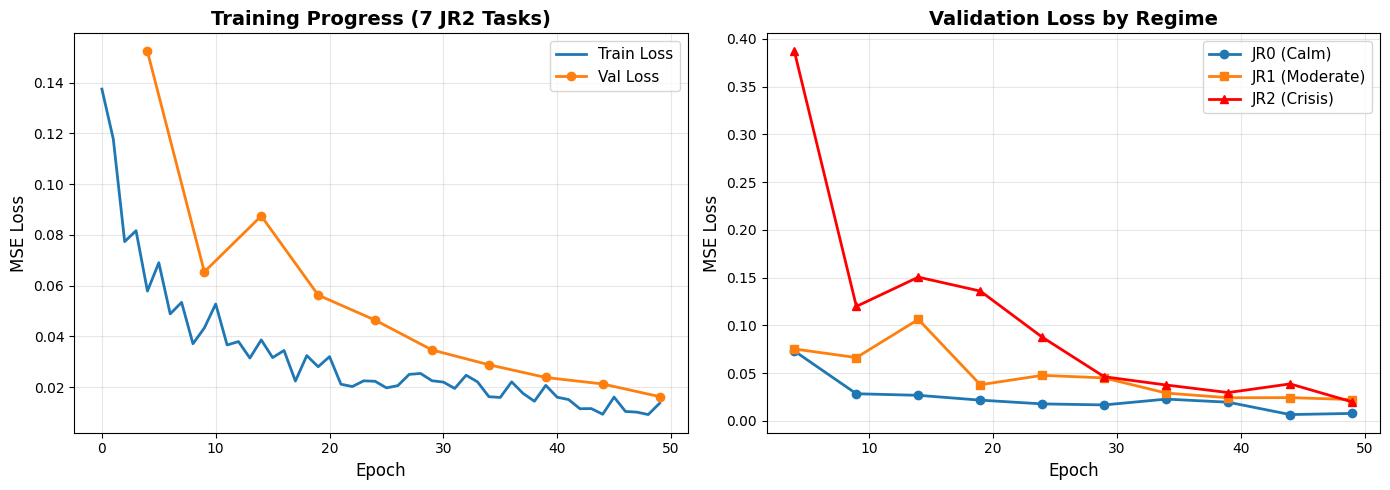


✅ Plot saved


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
val_epochs = list(range(4, EPOCHS, 5))
axes[0].plot(val_epochs, history['val_loss'], label='Val Loss', linewidth=2, marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Progress (7 JR2 Tasks)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Per-regime validation
axes[1].plot(val_epochs, history['val_regime_0'], label='JR0 (Calm)', linewidth=2, marker='o')
axes[1].plot(val_epochs, history['val_regime_1'], label='JR1 (Moderate)', linewidth=2, marker='s')
axes[1].plot(val_epochs, history['val_regime_2'], label='JR2 (Crisis)', linewidth=2, marker='^', color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Validation Loss by Regime', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('jm_maml_training_7tasks_20d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved")

## 💾 Save Results

In [19]:
# Save model
torch.save({
    'model_state_dict': best_model_state,
    'input_size': input_size,
    'hidden_size': HIDDEN_SIZE,
    'hyperparameters': {
        'inner_lr': INNER_LR,
        'outer_lr': OUTER_LR,
        'inner_steps': INNER_STEPS,
        'meta_batch_size': META_BATCH_SIZE,
        'epochs': EPOCHS
    },
    'experiment': '20d_threshold_7tasks'
}, 'jm_maml_model_7tasks_20d.pth')

# Save results
results = {
    'experiment': '20d_threshold',
    'jr2_task_count': len(jr2_tasks),
    'test_loss': float(test_loss),
    'regime_losses': {k: float(v) for k, v in test_regime_losses.items()},
    'crisis_tasks': crisis_results,
    'average_bias': float(avg_bias),
    'comparison_to_original': {
        'original_jr2_count': 5,
        'new_jr2_count': len(jr2_tasks),
        'original_test_loss': 0.0391,
        'new_test_loss': float(test_loss),
        'original_bias': -0.071,
        'new_bias': float(avg_bias)
    }
}

with open('jm_maml_results_7tasks_20d.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save crisis analysis
crisis_df.to_csv('jm_crisis_analysis_7tasks_20d.csv', index=False)

print("\n✅ All results saved:")
print("  - jm_maml_model_7tasks_20d.pth")
print("  - jm_maml_results_7tasks_20d.json")
print("  - jm_crisis_analysis_7tasks_20d.csv")
print("  - jm_maml_training_7tasks_20d.png")


✅ All results saved:
  - jm_maml_model_7tasks_20d.pth
  - jm_maml_results_7tasks_20d.json
  - jm_crisis_analysis_7tasks_20d.csv
  - jm_maml_training_7tasks_20d.png


## 📤 Upload to Google Drive

In [20]:
# Copy results to Drive
!mkdir -p /content/drive/MyDrive/maml_jm_experiments/7tasks_20d/
!cp jm_maml_model_7tasks_20d.pth /content/drive/MyDrive/maml_jm_experiments/7tasks_20d/
!cp jm_maml_results_7tasks_20d.json /content/drive/MyDrive/maml_jm_experiments/7tasks_20d/
!cp jm_crisis_analysis_7tasks_20d.csv /content/drive/MyDrive/maml_jm_experiments/7tasks_20d/
!cp jm_maml_training_7tasks_20d.png /content/drive/MyDrive/maml_jm_experiments/7tasks_20d/

print("✅ All results uploaded to Google Drive!")
print("   Location: MyDrive/maml_jm_experiments/7tasks_20d/")

✅ All results uploaded to Google Drive!
   Location: MyDrive/maml_jm_experiments/7tasks_20d/


## 🎯 Next Steps (ONLY if results are promising)

### If Bias Improved Significantly (-7.1% → <-5%):
✅ **Consider trying:**
1. International markets (Europe, Asia) for more crises
2. Longer time series (1980s data if available)

### If Bias NOT Improved (-7.1% → -6.5% or worse):
⚠️ **Don't try advanced methods yet:**
- ❌ Transformer-based MAML (overkill for 7 tasks)
- ❌ Hierarchical MAML (needs 15+ tasks per level)
- ❌ Multi-task MAML (adds complexity)

✅ **Instead, accept current results:**
- Write up findings honestly
- Document limitation (small sample size)
- -7% bias is acceptable for risk management

---

## 💡 Key Takeaway

**The 20d threshold experiment tests whether:**
- Short crises add meaningful diversity → Bias improves
- OR: Fundamental data limitation → No improvement

**Based on results, you'll know:**
- If more data helps → Get international markets
- If data doesn't help → Accept results, document limitation

**Don't overcomplicate until you see these results!**

---